In [1]:
import os
import torch
import mlflow
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torch.utils.data import Dataset, DataLoader, ConcatDataset
import torchvision.transforms as T
import torch.nn.functional as F
from tqdm.auto import tqdm

# Diffusers & PEFT imports
from diffusers import AutoencoderKL, UNet2DConditionModel, ControlNetModel, StableDiffusionControlNetPipeline, DDPMScheduler
from transformers import CLIPTextModel, CLIPTokenizer
from peft import LoraConfig, get_peft_model

In [2]:
# =====================================
# Random seed to ensure reproducibility
# =====================================
def set_seed(seed=42):
    # 1. Native python seed:
    random.seed(seed)

    # 2. Evironment python seed:
    os.environ['PYTHONHASHSEED'] = str(seed)
    
    # 3. Numpy seed:
    np.random.seed(seed)
    
    # 4. PyTorch seed (CPU)
    torch.manual_seed(seed)
    
    # 5. PyTorch seed (GPU / CUDA)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) # Si usas múltiples GPUs
    
    # 6. CuDNN deterministic for stability in math operations:
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42) # Call seed function

In [3]:
# 1. Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on device: {device}")

# 2. Base model IDs
model_id = "runwayml/stable-diffusion-v1-5"
controlnet_id = "lllyasviel/sd-controlnet-canny"

print("Loading base models and ControlNet...")

# A. Tokenizer and Text Encoder
tokenizer = CLIPTokenizer.from_pretrained(model_id, subfolder="tokenizer")
text_encoder = CLIPTextModel.from_pretrained(model_id, subfolder="text_encoder").to(device)

# B. VAE and U-Net
vae = AutoencoderKL.from_pretrained(model_id, subfolder="vae").to(device)
unet = UNet2DConditionModel.from_pretrained(model_id, subfolder="unet").to(device)

# C. ControlNet (NEW: For geometric boundaries)
controlnet = ControlNetModel.from_pretrained(controlnet_id).to(device)

# 3. FREEZE BASE MODELS & CONTROLNET
vae.requires_grad_(False) 
text_encoder.requires_grad_(False)
unet.requires_grad_(False)
controlnet.requires_grad_(False) # We don't train ControlNet, we just use it!

Training on device: cuda
Loading base models and ControlNet...


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: runwayml/stable-diffusion-v1-5
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
c:\ProgramData\anaconda3\envs\diffusion_models\lib\site-packages\huggingface_hub\utils\_validators.py:206: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


ControlNetModel(
  (conv_in): Conv2d(4, 320, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (time_proj): Timesteps()
  (time_embedding): TimestepEmbedding(
    (linear_1): Linear(in_features=320, out_features=1280, bias=True)
    (act): SiLU()
    (linear_2): Linear(in_features=1280, out_features=1280, bias=True)
  )
  (controlnet_cond_embedding): ControlNetConditioningEmbedding(
    (conv_in): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (blocks): ModuleList(
      (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): Conv2d(32, 96, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (4): Conv2d(96, 96, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (5): Conv2d(96, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    )
    (conv_out): Conv2d(256, 320, ker

In [4]:
# 4. CONFIGURATION OF LORA
lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    init_lora_weights="gaussian",
    target_modules=["to_k", "to_q", "to_v", "to_out.0"] 
)

# Inject LoRA
unet = get_peft_model(unet, lora_config)
unet.print_trainable_parameters()

optimizer = torch.optim.AdamW(unet.parameters(), lr=1e-4)

trainable params: 1,594,368 || all params: 861,115,332 || trainable%: 0.1852


In [5]:
class CastingDataset(Dataset):
    def __init__(self, image_dir, canny_dir, tokenizer, size=256):
        self.image_dir = image_dir
        self.canny_dir = canny_dir
        self.tokenizer = tokenizer
        
        self.text_files = [f for f in os.listdir(image_dir) if f.endswith('.txt')]
        
        # Original Image Transform (Needs to be [-1, 1] for VAE)
        self.transform_rgb = T.Compose([
            T.Resize((size, size)),
            T.ToTensor(),
            T.Normalize([0.5], [0.5]) 
        ])
        
        # Canny Image Transform (Needs to be [0, 1] for ControlNet!)
        self.transform_canny = T.Compose([
            T.Resize((size, size)),
            T.ToTensor()
        ])

    def __len__(self):
        return len(self.text_files)

    def __getitem__(self, idx):
        txt_name = self.text_files[idx]
        with open(os.path.join(self.image_dir, txt_name), 'r') as f:
            text = f.read().strip()
            
        text_inputs = self.tokenizer(
            text, padding="max_length", max_length=self.tokenizer.model_max_length, 
            truncation=True, return_tensors="pt"
        )
        
        img_name = txt_name.replace('.txt', '.jpeg') # Change to .png if necessary
        
        # Read RGB image
        img_path = os.path.join(self.image_dir, img_name)
        image = Image.open(img_path).convert("RGB")
        image = self.transform_rgb(image)
        
        # Read Canny Edge map
        canny_path = os.path.join(self.canny_dir, img_name)
        canny_image = Image.open(canny_path).convert("RGB")
        canny_tensor = self.transform_canny(canny_image)
        
        return {
            "pixel_values": image, 
            "canny_values": canny_tensor,
            "input_ids": text_inputs.input_ids.squeeze()
        }

In [6]:
# ==============================================================================
# Instantiate Datasets
# ==============================================================================
TARGET_SIZE = 256

PATH_OK = f"../data/processed/casting/casting_{TARGET_SIZE}x{TARGET_SIZE}/ok_front/images/"
CANNY_OK = f"../data/processed/casting/casting_{TARGET_SIZE}x{TARGET_SIZE}/ok_front/canny/"

PATH_DEF = f"../data/processed/casting/casting_{TARGET_SIZE}x{TARGET_SIZE}/def_front/images/"
CANNY_DEF = f"../data/processed/casting/casting_{TARGET_SIZE}x{TARGET_SIZE}/def_front/canny/"

dataset_ok = CastingDataset(PATH_OK, CANNY_OK, tokenizer, size=TARGET_SIZE)
dataset_def = CastingDataset(PATH_DEF, CANNY_DEF, tokenizer, size=TARGET_SIZE)

full_dataset = ConcatDataset([dataset_ok, dataset_def])
train_dataloader = DataLoader(full_dataset, batch_size=8, shuffle=True) # Batch 8 safe for VRAM with Canny

In [7]:
noise_scheduler = DDPMScheduler.from_pretrained(model_id, subfolder="scheduler")

# --- HYPERPARAMETERS & EXPERIMENT TRACKING ---
ENABLE_TRAINING = True # Set to True to enable training loop

EXPERIMENT_NAME = "Stable_Diffusion_Casting"
EPOCHS = 50 # Hypothesis testing
VALIDATION_EPOCHS = 5 # Generate a test image every 5 epochs
global_step = 0
run_name = "LoRA_ControlNet_Canny_v2"

# Validation parameters
val_prompt = (
    "photo of SKS_PART, top-down industrial inspection, circular machined component, "
    "flat grey ferrous material, severe porosity defect, surface blowholes and cavities, "
    "QC failed manufacturing reject, neutral factory lighting, plain background"
    )

val_negative_prompt = (
    "relic, antique, museum, face, skull, mask, statue, bronze, gold, jewelry, "
    "ornate, complex shape, intricate, art, shiny, colorful, 3d render"
)

val_canny_path = os.path.join(CANNY_DEF, os.listdir(CANNY_DEF)[0]) # Pick first canny image for testing
val_canny_image = Image.open(val_canny_path).convert("RGB").resize((TARGET_SIZE, TARGET_SIZE))

c:\ProgramData\anaconda3\envs\diffusion_models\lib\site-packages\mlflow\tracking\_tracking_service\utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)
2026/03/30 23:51:30 INFO mlflow.tracking.fluent: Experiment with name 'Stable_Diffusion_Casting' does not exist. Creating a new experiment.


Starting MLflow run: LoRA_ControlNet_Canny_v2 for 50 epochs...


Epoch 1/50:   0%|          | 0/163 [00:00<?, ?it/s]

Epoch 2/50:   0%|          | 0/163 [00:00<?, ?it/s]

Epoch 3/50:   0%|          | 0/163 [00:00<?, ?it/s]

...

Epoch 48/50:   0%|          | 0/163 [00:00<?, ?it/s]

Epoch 49/50:   0%|          | 0/163 [00:00<?, ?it/s]

Epoch 50/50:   0%|          | 0/163 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.controlnet.pipeline_controlnet.StableDiffusionControlNetPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .



🔍 Generating validation image for Epoch 50...
Training complete! Model logged to MLflow.

Final Validation Output:


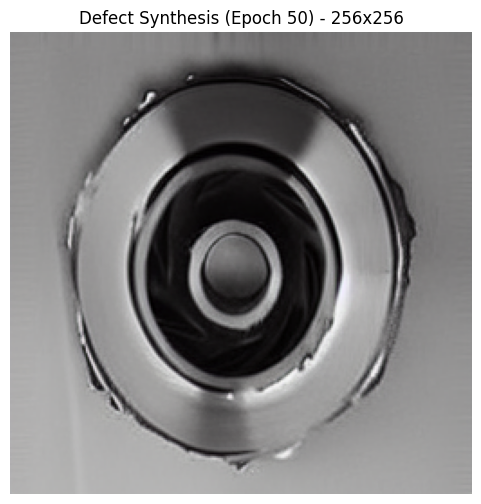

In [8]:
if ENABLE_TRAINING:

    unet.train() # Set U-Net to training mode (ControlNet stays in eval mode since it's frozen)

    # 1. Start MLflow Run
    mlflow.set_experiment(EXPERIMENT_NAME)

    with mlflow.start_run(run_name=run_name):
        # Log parameters
        mlflow.log_params({
            "epochs": EPOCHS,
            "batch_size": train_dataloader.batch_size,
            "learning_rate": 1e-4,
            "resolution": TARGET_SIZE,
            "lora_rank": lora_config.r,
            "controlnet": "canny"
        })

        print(f"Starting MLflow run: {run_name} for {EPOCHS} epochs...")
        last_val_image = None # To display at the very end

        for epoch in range(EPOCHS):
            progress_bar = tqdm(total=len(train_dataloader), desc=f"Epoch {epoch+1}/{EPOCHS}")
            epoch_loss = 0.0

            for batch in train_dataloader:
                with torch.no_grad():
                    latents = vae.encode(batch["pixel_values"].to(device)).latent_dist.sample()
                    latents = latents * vae.config.scaling_factor 
                    encoder_hidden_states = text_encoder(batch["input_ids"].to(device))[0]

                noise = torch.randn_like(latents)
                batch_size = latents.shape[0]
                timesteps = torch.randint(0, noise_scheduler.config.num_train_timesteps, (batch_size,), device=latents.device).long()
                noisy_latents = noise_scheduler.add_noise(latents, noise, timesteps)

                # --- CONTROLNET FORWARD PASS ---
                down_block_res_samples, mid_block_res_sample = controlnet(
                    noisy_latents, timesteps,
                    encoder_hidden_states=encoder_hidden_states,
                    controlnet_cond=batch["canny_values"].to(device), # Inject Canny edges
                    return_dict=False,
                )

                # --- U-NET FORWARD PASS (Guided by ControlNet) ---
                model_pred = unet(
                    noisy_latents, timesteps,
                    encoder_hidden_states=encoder_hidden_states,
                    down_block_additional_residuals=down_block_res_samples,
                    mid_block_additional_residual=mid_block_res_sample,
                ).sample

                # Calculate Loss & Backprop
                loss = F.mse_loss(model_pred.float(), noise.float(), reduction="mean")
                loss.backward()
                optimizer.step()
                optimizer.zero_grad() 

                progress_bar.update(1)
                progress_bar.set_postfix({"loss": f"{loss.item():.4f}"})
                epoch_loss += loss.item()
                global_step += 1
                
                # Log loss to MLflow per step
                mlflow.log_metric("step_loss", loss.item(), step=global_step)
                
            avg_loss = epoch_loss / len(train_dataloader)
            mlflow.log_metric("epoch_avg_loss", avg_loss, step=epoch)
            
            # ======================================================================
            # VALIDATION STAGE: Check progress without stopping training
            # ======================================================================
            if (epoch + 1) % VALIDATION_EPOCHS == 0 or (epoch + 1) == EPOCHS:
                print(f"\n🔍 Generating validation image for Epoch {epoch + 1}...")
                
                # We use the pipeline temporarily using our currently trained components
                val_pipe = StableDiffusionControlNetPipeline(
                    vae=vae, text_encoder=text_encoder, tokenizer=tokenizer, unet=unet,
                    controlnet=controlnet, scheduler=noise_scheduler, 
                    safety_checker=None, feature_extractor=None
                )
                val_pipe.set_progress_bar_config(disable=True)
                
                # Generate image constrained by Canny
                val_result = val_pipe(
                    prompt=val_prompt, image=val_canny_image,
                    negative_prompt=val_negative_prompt,
                    num_inference_steps=20, guidance_scale=7.5
                ).images[0]
                
                last_val_image = val_result
                
                # Save locally and send to MLflow as artifact
                val_img_name = f"val_epoch_{epoch+1}.png"
                val_result.save(val_img_name)
                mlflow.log_artifact(val_img_name, artifact_path="validation_images")
                os.remove(val_img_name) # Clean up local disk

        # End of Training
        save_path = "../models/sd_lora_casting_v2"
        unet.save_pretrained(save_path)
        mlflow.log_artifacts(save_path, artifact_path="lora_weights")
        print(f"Training complete! Model logged to MLflow.")

    # 4. Show ONLY the final validation image in the notebook for GitHub viewing
    if last_val_image:
        print("\nFinal Validation Output:")
        plt.figure(figsize=(6, 6))
        plt.imshow(last_val_image)
        plt.axis("off")
        plt.title(f"Defect Synthesis (Epoch {EPOCHS}) - {TARGET_SIZE}x{TARGET_SIZE}")
        plt.show()

Reconstructing exact training environment...
Injecting PEFT Adapter into U-Net...


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: C:\Users\estiv\.cache\huggingface\hub\models--runwayml--stable-diffusion-v1-5\snapshots\451f4fe16113bff5a5d2269ed5ad43b0592e9a14\safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

...

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

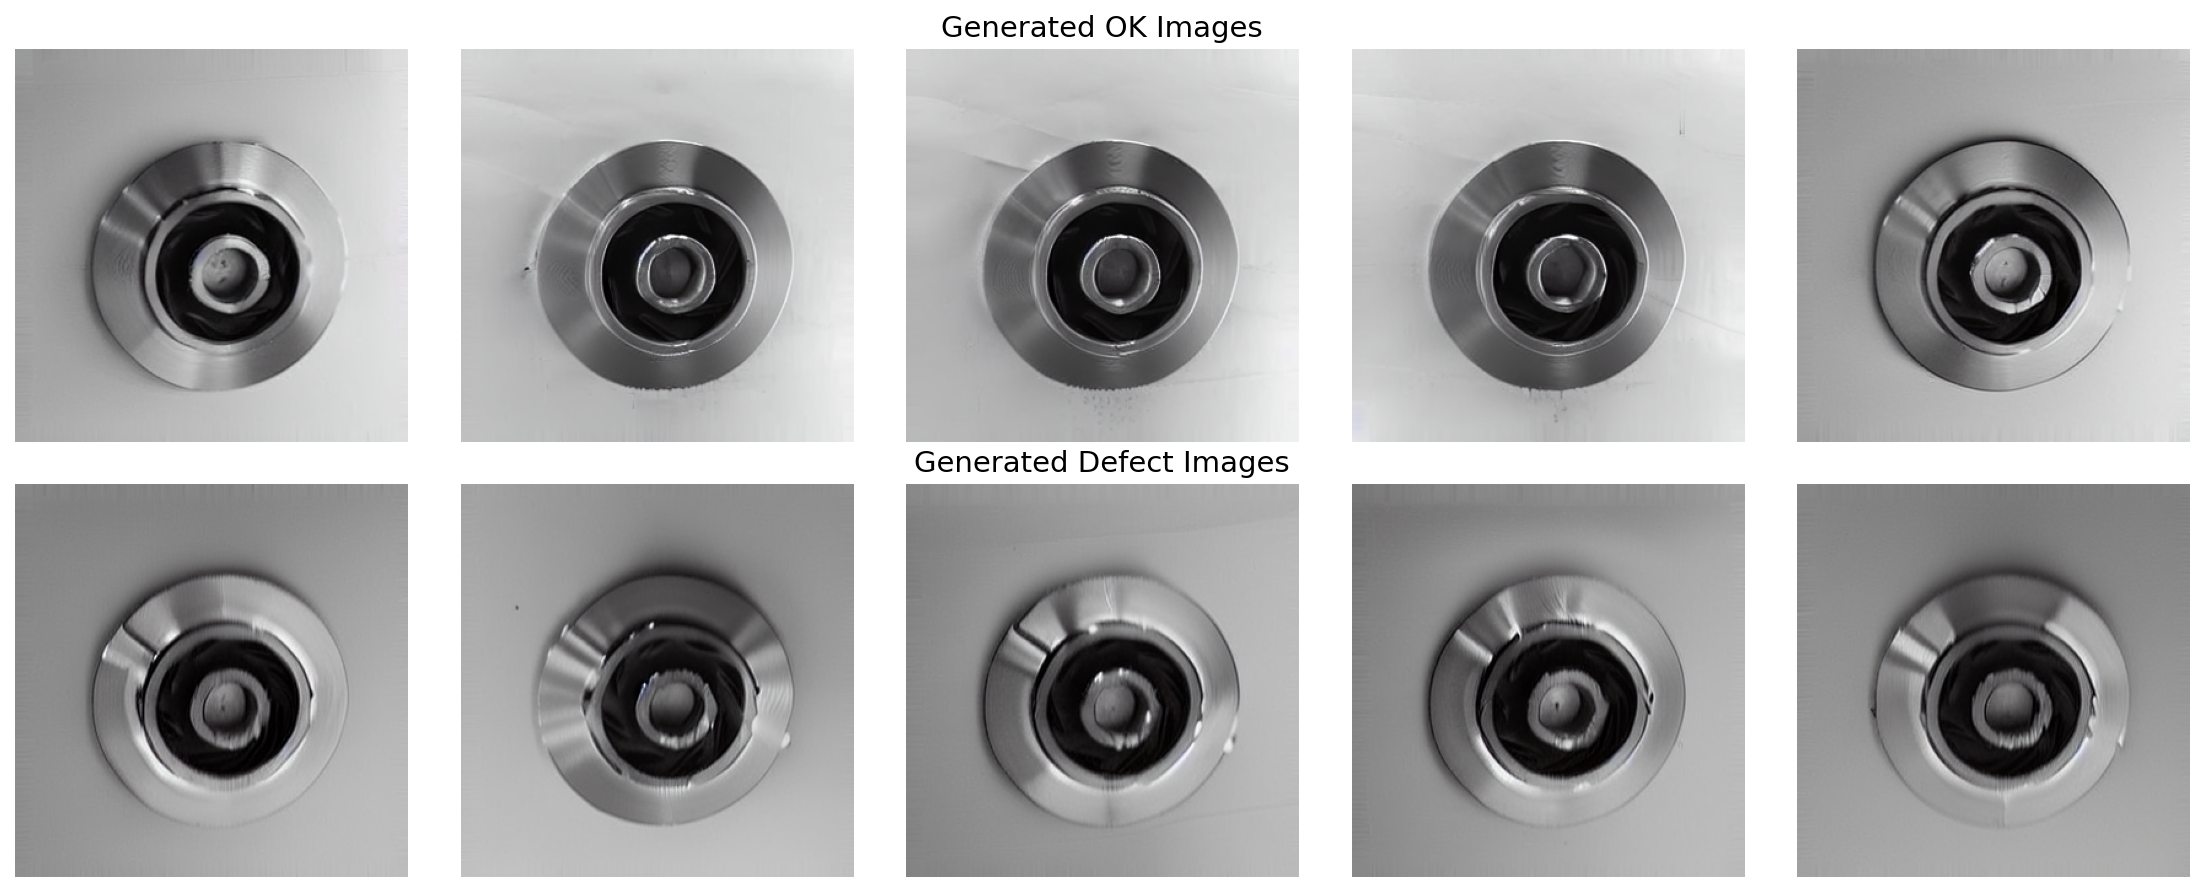

In [12]:
import os
import torch
import matplotlib.pyplot as plt
from PIL import Image
from diffusers import StableDiffusionControlNetPipeline, ControlNetModel, UNet2DConditionModel, DDPMScheduler
from peft import PeftModel

# ==============================================================================
# 1. Hardware Configuration and Paths
# ==============================================================================
device = "cuda"
model_id = "runwayml/stable-diffusion-v1-5"
controlnet_id = "lllyasviel/sd-controlnet-canny"
lora_path = "../models/sd_lora_casting_v2" 
TARGET_SIZE = 320

print("Reconstructing exact training environment...")

# ==============================================================================
# 2. Load Base Components Manually
# ==============================================================================
# Load ControlNet
controlnet = ControlNetModel.from_pretrained(controlnet_id, torch_dtype=torch.float16).to(device)

# Load the base U-Net
base_unet = UNet2DConditionModel.from_pretrained(model_id, subfolder="unet", torch_dtype=torch.float16).to(device)

# ==============================================================================
# 3. INJECT LORA USING PEFT (The exact mathematical way it was trained)
# ==============================================================================
print("Injecting PEFT Adapter into U-Net...")
# This bypasses the diffusers loader and guarantees the exact same mathematical graph
unet = PeftModel.from_pretrained(base_unet, lora_path)
unet.eval() # Set to evaluation mode

# ==============================================================================
# 4. Build Pipeline with Exact Training Scheduler
# ==============================================================================
# During training, we used DDPMScheduler. We must use the exact same one here.
scheduler = DDPMScheduler.from_pretrained(model_id, subfolder="scheduler")

pipe = StableDiffusionControlNetPipeline.from_pretrained(
    model_id,
    unet=unet,             # Inject our PEFT-wrapped UNet
    controlnet=controlnet,
    scheduler=scheduler,   # Inject the training scheduler
    torch_dtype=torch.float16
).to(device)

pipe.safety_checker = None 

# ==============================================================================
# 5. Prompts and Image Loading
# ==============================================================================
prompt_ok = (
    "photo of SKS_PART, top-down industrial inspection, circular machined component, "
    "flat grey ferrous material, flawless smooth surface, QC passed, neutral factory lighting, "
    "plain background"
)

prompt_def = (
    "photo of SKS_PART, top-down industrial inspection, circular machined component, "
    "flat grey ferrous material, severe porosity defect, surface blowholes and cavities, "
    "QC failed manufacturing reject, neutral factory lighting, plain background"
)

negative_prompt = (
    "relic, antique, museum, face, skull, mask, statue, bronze, gold, jewelry, "
    "ornate, complex shape, intricate, art, shiny, colorful, 3d render"
)

canny_template_dir = "../data/processed/casting/casting_256x256/ok_front/canny/"
sample_canny_file = os.path.join(canny_template_dir, os.listdir(canny_template_dir)[0])
canny_image = Image.open(sample_canny_file).convert("RGB").resize((TARGET_SIZE, TARGET_SIZE), Image.Resampling.LANCZOS)

# ==============================================================================
# 6. Generate (Matching Validation Parameters)
# ==============================================================================
print(f"Generating 5 OK condition images at {TARGET_SIZE}x{TARGET_SIZE}...")
images_ok = []
base_seed = 42
for i in range(5):
    g_cuda = torch.Generator(device="cuda").manual_seed(base_seed + i) # Different seed for each image

    img = pipe(
        prompt=prompt_ok, 
        negative_prompt=negative_prompt, 
        image=canny_image,
        width=TARGET_SIZE,                     
        height=TARGET_SIZE,                    
        # MATCH EXACT TRAINING VALIDATION SETTINGS:
        num_inference_steps=20, # In the training loop, validation was 20 steps
        guidance_scale=7.5,     # In the training loop, validation was 7.5
        generator=g_cuda,
    ).images[0]
    images_ok.append(img)

print(f"Generating 5 Defective condition images at {TARGET_SIZE}x{TARGET_SIZE}...")
images_def = []
for i in range(5):
    g_cuda = torch.Generator(device="cuda").manual_seed(base_seed + i) # Different seed for each image
    img = pipe(
        prompt=prompt_def, 
        negative_prompt=negative_prompt, 
        image=canny_image,
        width=TARGET_SIZE,                     
        height=TARGET_SIZE,                    
        num_inference_steps=20, 
        guidance_scale=7.5,
        generator=g_cuda,
    ).images[0]
    images_def.append(img)

# ==============================================================================
# 7. Plot the Grid
# ==============================================================================
fig, axes = plt.subplots(2, 5, figsize=(15, 6), dpi=150)

for i in range(5):
    axes[0, i].imshow(images_ok[i])
    axes[0, i].axis('off')
    if i == 2:
        axes[0, i].set_title(f"Generated OK Images", fontsize=14)

for i in range(5):
    axes[1, i].imshow(images_def[i])
    axes[1, i].axis('off')
    if i == 2:
        axes[1, i].set_title(f"Generated Defect Images", fontsize=14)

plt.tight_layout()
plt.show()

Calculating text embeddings for arithmetic progression...
Generating progression with ControlNet geometry constraints...


  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

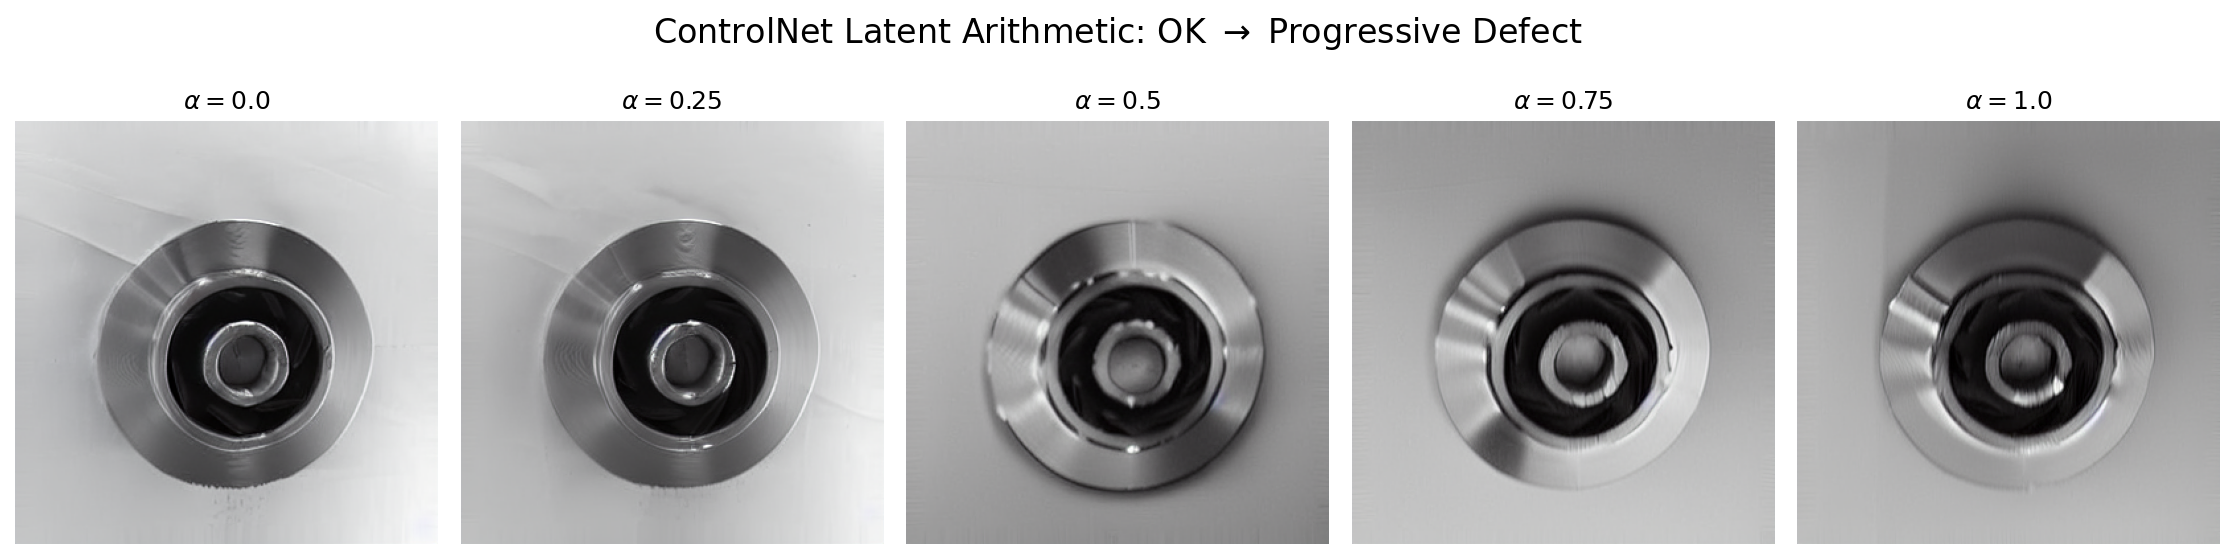

In [10]:
import torch
import matplotlib.pyplot as plt

print("Calculating text embeddings for arithmetic progression...")

# ==============================================================================
# 1. Helper function to get Text Embeddings directly from the prompt
# ==============================================================================
def get_text_embeddings(prompt, pipeline):
    text_inputs = pipeline.tokenizer(
        prompt, 
        padding="max_length", 
        max_length=pipeline.tokenizer.model_max_length, 
        truncation=True, 
        return_tensors="pt"
    )
    with torch.no_grad():
        embeddings = pipeline.text_encoder(text_inputs.input_ids.to(pipeline.device))[0]
    return embeddings

# Get embeddings using the sterile prompts we defined in the previous cell
embed_ok = get_text_embeddings(prompt_ok, pipe)
embed_def = get_text_embeddings(prompt_def, pipe)
embed_negative = get_text_embeddings(negative_prompt, pipe)

# ==============================================================================
# 2. Define Alphas for progression (0.0 = 100% OK, 1.0 = 100% Defect)
# ==============================================================================
alphas = [0.0, 0.25, 0.5, 0.75, 1.0]
images_progression = []

# ==============================================================================
# 3. FIX THE LATENT NOISE (Seed) AND UPDATE RESOLUTION
# ==============================================================================
# This guarantees the background noise stays EXACTLY the same.
# We also update the resolution math for 256x256 (256 // 8 = 32)
TARGET_SIZE = 320
generator = torch.Generator(device="cuda").manual_seed(42) # Try changing 42 to explore other base textures

# The starting latent noise structure requires matching spatial dimensions
starting_latents = torch.randn(
    (1, pipe.unet.config.in_channels, TARGET_SIZE // 8, TARGET_SIZE // 8),
    generator=generator,
    device="cuda",
    dtype=torch.float16
)

print("Generating progression with ControlNet geometry constraints...")

# ==============================================================================
# 4. Interpolate and Generate (MATCHING PEFT PIPELINE PARAMS)
# ==============================================================================
for alpha in alphas:
    # Linear Interpolation of the concepts 
    interp_embeds = (1.0 - alpha) * embed_ok + alpha * embed_def
    
    # Generate image using mathematical embeddings AND the ControlNet edge map
    img = pipe(
        prompt_embeds=interp_embeds,
        negative_prompt_embeds=embed_negative,
        image=canny_image,               # <--- CRITICAL: Locks the geometric shape!
        width=TARGET_SIZE,               # Match training resolution
        height=TARGET_SIZE,              # Match training resolution
        latents=starting_latents.clone(), # VERY IMPORTANT to clone so the base noise doesn't degrade
        num_inference_steps=20,          # Matched to training validation steps
        guidance_scale=7.5               # Matched to training validation CFG
    ).images[0]
    
    images_progression.append(img)

# ==============================================================================
# 5. Plot the 1x5 Progression
# ==============================================================================
fig, axes = plt.subplots(1, 5, figsize=(15, 4), dpi=150)

for i, alpha in enumerate(alphas):
    axes[i].imshow(images_progression[i])
    axes[i].axis('off')
    # Use LaTeX formatting for the alpha symbol in the plot title
    axes[i].set_title(r"$\alpha = {}$".format(alpha), fontsize=12)

plt.suptitle(r"ControlNet Latent Arithmetic: OK $\rightarrow$ Progressive Defect", fontsize=16)
plt.tight_layout()
plt.show()